Distribusi Label Sebelum Balancing:
label
positif    5342
negatif    3616
netral      443
Name: count, dtype: int64

Distribusi Label Sesudah Balancing:
label
negatif    5342
positif    5342
netral     5342
Name: count, dtype: int64


/tmp/ipykernel_2140/2812782277.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', order=['negatif', 'netral', 'positif'], palette='viridis')
/tmp/ipykernel_2140/2812782277.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_balanced, x='label', order=['negatif', 'netral', 'positif'], palette='viridis')


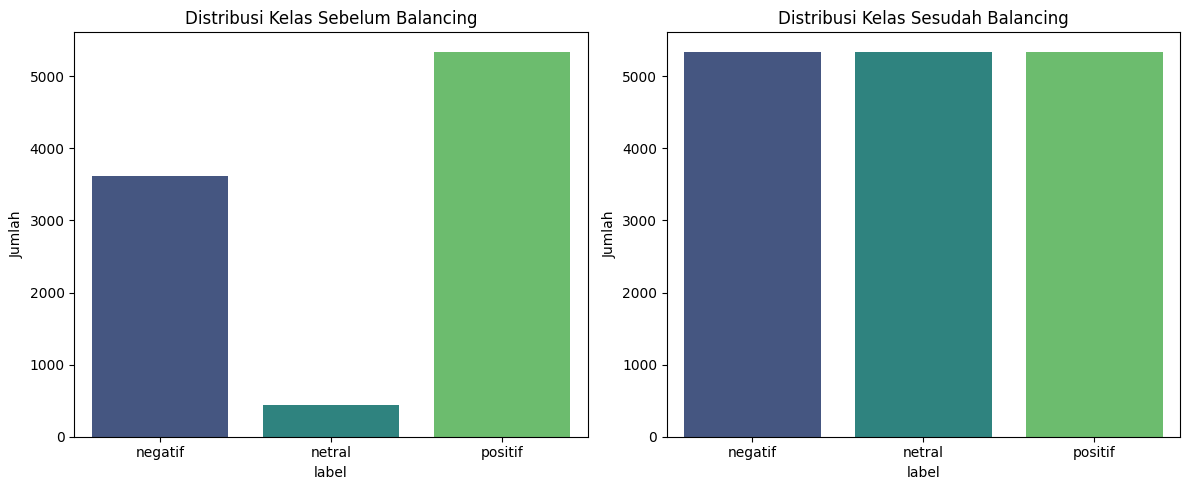

✅ Dataset final yang sudah seimbang (balanced) berhasil disimpan ke dataset_final.csv
Total data sekarang: 16026 ulasan (Siap untuk dipreprocessing ulang dan dilatih!)


In [ ]:
# ============================================================
# TAHAP 2B: PENANGANAN CLASS IMBALANCE & VISUALISASI
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample

# Load data gabungan
df = pd.read_csv('dataset_gabungan.csv')

print("Distribusi Label Sebelum Balancing:")
print(df['label'].value_counts())

# Plot sebelum balancing
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='label', order=['negatif', 'netral', 'positif'], palette='viridis')
plt.title('Distribusi Kelas Sebelum Balancing')
plt.ylabel('Jumlah')

# ============================================================
# MANUAL OVERSAMPLING
# ============================================================
# Memisahkan data berdasarkan kelas
df_neg = df[df['label'] == 'negatif']
df_pos = df[df['label'] == 'positif']
df_net = df[df['label'] == 'netral']

# Cari jumlah dari kelas mayoritas (nilai maksimum)
majority_count = max(len(df_neg), len(df_pos), len(df_net))

# Lakukan oversampling (duplikasi sampel acak) pada kelas minoritas agar setara dengan kelas mayoritas
df_neg_over = resample(df_neg, replace=True, n_samples=majority_count, random_state=42)
df_pos_over = resample(df_pos, replace=True, n_samples=majority_count, random_state=42)
df_net_over = resample(df_net, replace=True, n_samples=majority_count, random_state=42)

# Gabungkan kembali menjadi dataset yang seimbang
df_balanced = pd.concat([df_neg_over, df_pos_over, df_net_over])

print("\nDistribusi Label Sesudah Balancing:")
print(df_balanced['label'].value_counts())

# Plot sesudah balancing
plt.subplot(1, 2, 2)
sns.countplot(data=df_balanced, x='label', order=['negatif', 'netral', 'positif'], palette='viridis')
plt.title('Distribusi Kelas Sesudah Balancing')
plt.ylabel('Jumlah')

plt.tight_layout()
plt.show()

# ============================================================
# SIMPAN DATASET FINAL
# ============================================================
df_balanced.to_csv('dataset_final.csv', index=False)
print("✅ Dataset final yang sudah seimbang (balanced) berhasil disimpan ke dataset_final.csv")
print(f"Total data sekarang: {len(df_balanced)} ulasan (Siap untuk dipreprocessing ulang dan dilatih!)")

Total data: 16026
Kolom tersedia: ['username', 'review', 'rating', 'date', 'app', 'label']

📊 Distribusi Label:
label
negatif    5342
positif    5342
netral     5342
Name: count, dtype: int64

label
negatif    33.3
positif    33.3
netral     33.3
Name: proportion, dtype: float64

⚠️  Data dengan label tidak valid: 0
✅ Total data bersih: 16026


/tmp/ipykernel_2140/1607777635.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


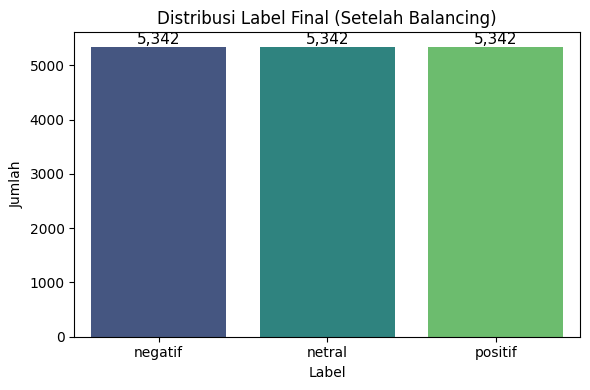


✅ dataset_labeled.csv berhasil disimpan!
   → 16026 baris siap masuk Tahap 3 Preprocessing


,username,review,rating,label
0,Pengguna Google,"kebijakannya menyusahkan, saya udh dpt driver ...",1,negatif
1,Pengguna Google,"lama sekali dapet drivernya, sampai tak coba s...",1,negatif
2,Pengguna Google,order pake gofood minta cocacola dikirimnya fa...,2,negatif
3,Pengguna Google,sudah beberapa hari ini tidak bisa dapat drive...,2,negatif
4,Pengguna Google,"ekspres apaan, driver gak ada yg mau ambil, la...",1,negatif


In [ ]:
# ============================================================
# TAHAP 2 (REVISI): VALIDASI LABEL DARI DATASET FINAL
# Membaca dataset_final.csv yang sudah balanced (15.930 data)
# hasil dari Tahap 2B, bukan scraping ulang
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Baca dataset final yang sudah balanced dari Tahap 2B
df = pd.read_csv('dataset_final.csv')

print(f"Total data: {len(df)}")
print(f"Kolom tersedia: {list(df.columns)}")

# ============================================================
# Validasi kolom label sudah ada
# ============================================================
assert 'label' in df.columns, "❌ Kolom label tidak ditemukan!"
assert 'review' in df.columns, "❌ Kolom review tidak ditemukan!"

print("\n📊 Distribusi Label:")
print(df['label'].value_counts())
print()
print(df['label'].value_counts(normalize=True).round(3) * 100)

# ============================================================
# Pastikan tidak ada label di luar 3 kelas
# ============================================================
valid_labels = {'negatif', 'netral', 'positif'}
invalid = df[~df['label'].isin(valid_labels)]
print(f"\n⚠️  Data dengan label tidak valid: {len(invalid)}")

# Hapus jika ada
df = df[df['label'].isin(valid_labels)]
df = df.dropna(subset=['review', 'label'])
df = df[df['review'].str.strip() != '']

print(f"✅ Total data bersih: {len(df)}")

# ============================================================
# Visualisasi distribusi label final
# ============================================================
plt.figure(figsize=(6, 4))
ax = sns.countplot(
    data=df,
    x='label',
    order=['negatif', 'netral', 'positif'],
    palette='viridis'
)
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=11
    )
plt.title('Distribusi Label Final (Setelah Balancing)')
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

# ============================================================
# Simpan sebagai dataset_labeled.csv
# agar Tahap 3 bisa membacanya tanpa perubahan
# ============================================================
df.to_csv('dataset_labeled.csv', index=False)
print("\n✅ dataset_labeled.csv berhasil disimpan!")
print(f"   → {len(df)} baris siap masuk Tahap 3 Preprocessing")
df[['username', 'review', 'rating', 'label']].head()

In [ ]:
# ============================================================
# TAHAP 3 (REVISI): TEXT PREPROCESSING
# Input : dataset_labeled.csv (15.930 data, 3 kelas balanced)
# Output: dataset_preprocessed.csv
# ============================================================

import re
import string
import nltk
import pandas as pd

# Install jika belum ada
!pip install Sastrawi

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# ============================================================
# Inisialisasi Stemmer & Stopwords
# ============================================================
factory    = StemmerFactory()
stemmer    = factory.create_stemmer()
stop_words = set(stopwords.words('indonesian'))

# Tambah stopwords custom (kata yang tidak bermakna sentimen)
custom_stopwords = {
    'app', 'apps', 'application', 'aplk', 'apk',
    'gojek', 'grab', 'maxim', 'driver', 'ojek',
    'nya', 'yg', 'dgn', 'jg', 'krn', 'klo', 'kl',
    'udh', 'udah', 'dah', 'deh', 'dong', 'sih',
    'aja', 'aj', 'doang', 'doank',
}
stop_words.update(custom_stopwords)

# ============================================================
# Kamus Normalisasi Slang Indonesia
# ============================================================
slang_dict = {
    # Negasi & kata umum
    'gk'    : 'tidak', 'gak'  : 'tidak', 'ga'   : 'tidak',
    'ngga'  : 'tidak', 'nggak': 'tidak', 'enggak': 'tidak',
    'tdk'   : 'tidak', 'tak'  : 'tidak',
    # Intensifier
    'bgt'   : 'banget', 'bngt' : 'banget', 'bgtt' : 'banget',
    'bangeett': 'banget',
    'sgt'   : 'sangat', 'sngt' : 'sangat',
    'byk'   : 'banyak', 'bnyk' : 'banyak',
    # Kata kerja / sifat umum
    'msh'   : 'masih',  'masi' : 'masih',
    'udh'   : 'sudah',  'sdh'  : 'sudah',
    'blm'   : 'belum',  'blum' : 'belum',
    'lg'    : 'lagi',   'lgi'  : 'lagi',
    'lbh'   : 'lebih',  'lbih' : 'lebih',
    'krg'   : 'kurang', 'krng' : 'kurang',
    'bs'    : 'bisa',   'bsa'  : 'bisa',
    'hrs'   : 'harus',  'hrs'  : 'harus',
    'dtg'   : 'datang',
    'pgn'   : 'ingin',  'pngen': 'ingin',  'mau'  : 'ingin',
    # Kata sifat sentimen
    'ok'    : 'oke',    'oke'  : 'oke',
    'okelah': 'oke',
    'jos'   : 'bagus',  'joss' : 'bagus',
    'mantap': 'bagus',  'mantep': 'bagus',
    'keren' : 'bagus',  'kece' : 'bagus',
    'jelek' : 'buruk',  'jlek' : 'buruk',
    'parah' : 'buruk',  'prh'  : 'buruk',
    'ancur' : 'rusak',  'rusak': 'rusak',
    'lemot' : 'lambat', 'lmot' : 'lambat',
    'lelet' : 'lambat',
    'eror'  : 'error',  'erroe': 'error',
    'ngelag': 'lag',    'lag'  : 'lag',
    # Kata ganti & sapaan
    'sy'    : 'saya',   'aku'  : 'saya',  'gue'  : 'saya',
    'gw'    : 'saya',
    'km'    : 'kamu',   'kmu'  : 'kamu',  'lu'   : 'kamu',
    'lo'    : 'kamu',
    'mrk'   : 'mereka',
    # Kata lain
    'utk'   : 'untuk',  'tuk'  : 'untuk',
    'dgn'   : 'dengan', 'dng'  : 'dengan',
    'dr'    : 'dari',   'dri'  : 'dari',
    'pd'    : 'pada',
    'tp'    : 'tapi',   'ttp'  : 'tetapi',
    'krn'   : 'karena', 'karna': 'karena',
    'spy'   : 'supaya',
    'smg'   : 'semoga',
    'trm'   : 'terima', 'mksh' : 'makasih', 'thx'  : 'terima kasih',
    'tks'   : 'terima kasih',
    'tolong': 'tolong', 'tlng' : 'tolong',
    'cpt'   : 'cepat',  'cpet' : 'cepat',
    'lmn'   : 'lama',   'lama' : 'lama',
    'mhl'   : 'mahal',  'mhal' : 'mahal',
    'mrah'  : 'murah',  'mrh'  : 'murah',
    'aman'  : 'aman',   'nyaman': 'nyaman',
    'susah' : 'sulit',  'ribet': 'sulit',
    'mudah' : 'mudah',  'gmpng': 'mudah',
    'nambah': 'tambah', 'nambahkan': 'tambah',
}

# ============================================================
# Fungsi Normalisasi Slang
# ============================================================
def normalize_slang(text):
    tokens = text.split()
    tokens = [slang_dict.get(w, w) for w in tokens]
    return ' '.join(tokens)

# ============================================================
# Fungsi Preprocessing Lengkap
# ============================================================
def preprocess_text(text):
    if not isinstance(text, str):
        return ''

    # 1. Lowercase
    text = text.lower()

    # 2. Hapus URL
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3. Hapus mention & hashtag
    text = re.sub(r'@\w+|#\w+', '', text)

    # 4. Hapus angka
    text = re.sub(r'\d+', '', text)

    # 5. Hapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 6. Hapus whitespace berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    # 7. Normalisasi slang  ← BARU
    text = normalize_slang(text)

    # 8. Tokenisasi
    tokens = word_tokenize(text)

    # 9. Hapus stopwords
    tokens = [w for w in tokens if w not in stop_words and len(w) > 1]

    # 10. Stemming
    tokens = [stemmer.stem(w) for w in tokens]

    return ' '.join(tokens)

# ============================================================
# Terapkan ke dataset_labeled.csv (15.930 data)
# ============================================================
print("⏳ Memulai preprocessing 15.930 data...")
print("   Estimasi waktu: 5–10 menit, harap tunggu.\n")

df = pd.read_csv('dataset_labeled.csv')
df['review_clean'] = df['review'].apply(preprocess_text)

# Hapus review kosong setelah preprocessing
df = df[df['review_clean'].str.strip() != '']

print(f"✅ Preprocessing selesai!")
print(f"   Total data: {len(df)}")
print(f"\n📊 Distribusi label setelah preprocessing:")
print(df['label'].value_counts())

# ============================================================
# Contoh perbandingan sebelum vs sesudah
# ============================================================
print("\n📝 Contoh hasil preprocessing:")
contoh = df[['review', 'review_clean', 'label']].head(5)
for _, row in contoh.iterrows():
    print(f"\n  Asli    : {row['review'][:60]}")
    print(f"  Bersih  : {row['review_clean'][:60]}")
    print(f"  Label   : {row['label']}")

# ============================================================
# Simpan
# ============================================================
df.to_csv('dataset_preprocessed.csv', index=False)
print(f"\n✅ dataset_preprocessed.csv berhasil disimpan!")
print(f"   → {len(df)} baris siap masuk Tahap 4 Training")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.0 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


⏳ Memulai preprocessing 15.930 data...
   Estimasi waktu: 5–10 menit, harap tunggu.

✅ Preprocessing selesai!
   Total data: 15803

📊 Distribusi label setelah preprocessing:
label
negatif    5317
netral     5277
positif    5209
Name: count, dtype: int64

📝 Contoh hasil preprocessing:

  Asli    : kebijakannya menyusahkan, saya udh dpt driver jd merchant ud
  Bersih  : bijak susah dpt jd merchant masak cancel jam dpt makan jam l
  Label   : negatif

  Asli    : lama sekali dapet drivernya, sampai tak coba sampai 4x padah
  Bersih  : dapet drivernya coba jam dapet
  Label   : negatif

  Asli    : order pake gofood minta cocacola dikirimnya fanta. order 2 b
  Bersih  : order pake gofood cocacola kirim fanta order burger ayam ken
  Label   : negatif

  Asli    : sudah beberapa hari ini tidak bisa dapat driver untuk ordera
  Bersih  : order gofood pesan batal wajib nunggu jam dapet kalo masalh 
  Label   : negatif

  Asli    : ekspres apaan, driver gak ada yg mau ambil, lama banget tela
  B

In [ ]:
!pip install imbalanced-learn

Total data: 15803

📊 Distribusi label:
label
negatif    5317
netral     5277
positif    5209
Name: count, dtype: int64

Label mapping: {'negatif': np.int64(0), 'netral': np.int64(1), 'positif': np.int64(2)}

🔵 SKEMA 1: SVM + TF-IDF + 80/20

📊 Hasil: SVM TF-IDF 80/20
Akurasi Training : 0.9816  (98.16%)
Akurasi Testing  : 0.9503  (95.03%)
Status           : ✅ LULUS

Classification Report (Test):
              precision    recall  f1-score   support

     negatif       0.93      0.94      0.94      1064
      netral       0.96      0.99      0.98      1055
     positif       0.96      0.92      0.94      1042

    accuracy                           0.95      3161
   macro avg       0.95      0.95      0.95      3161
weighted avg       0.95      0.95      0.95      3161



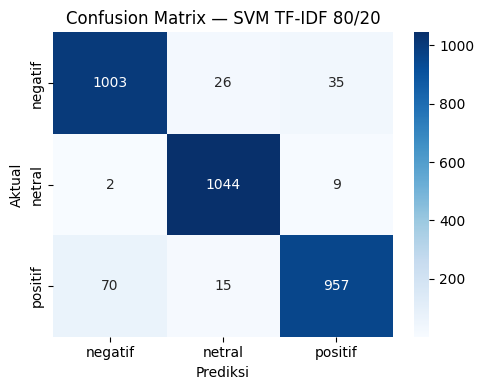


🟢 SKEMA 2: Logistic Regression + TF-IDF + 80/20

📊 Hasil: LR TF-IDF 80/20
Akurasi Training : 0.9731  (97.31%)
Akurasi Testing  : 0.9408  (94.08%)
Status           : ✅ LULUS

Classification Report (Test):
              precision    recall  f1-score   support

     negatif       0.93      0.92      0.92      1064
      netral       0.94      0.99      0.97      1055
     positif       0.95      0.92      0.93      1042

    accuracy                           0.94      3161
   macro avg       0.94      0.94      0.94      3161
weighted avg       0.94      0.94      0.94      3161



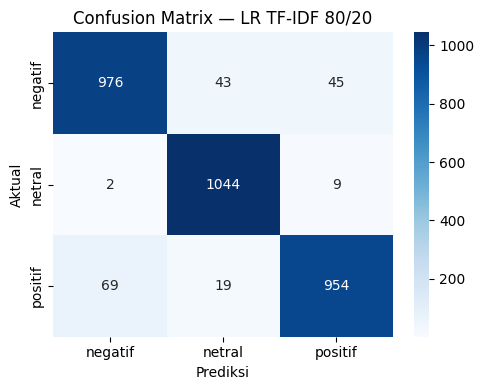


🟡 SKEMA 3: Random Forest + TF-IDF + 70/30

📊 Hasil: RF TF-IDF 70/30
Akurasi Training : 0.9926  (99.26%)
Akurasi Testing  : 0.9606  (96.06%)
Status           : ✅ LULUS

Classification Report (Test):
              precision    recall  f1-score   support

     negatif       0.94      0.95      0.95      1595
      netral       0.99      0.99      0.99      1583
     positif       0.95      0.94      0.94      1563

    accuracy                           0.96      4741
   macro avg       0.96      0.96      0.96      4741
weighted avg       0.96      0.96      0.96      4741



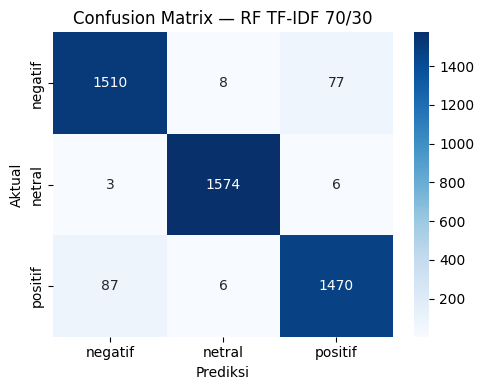


📈 RINGKASAN SEMUA SKEMA
Skema                           Train     Test  Status
----------------------------------------------------------
SVM+TF-IDF+80/20               98.16%    95.03%  ✅ LULUS
LR+TF-IDF+80/20                97.31%    94.08%  ✅ LULUS
RF+TF-IDF+70/30                99.26%    96.06%  ✅ LULUS


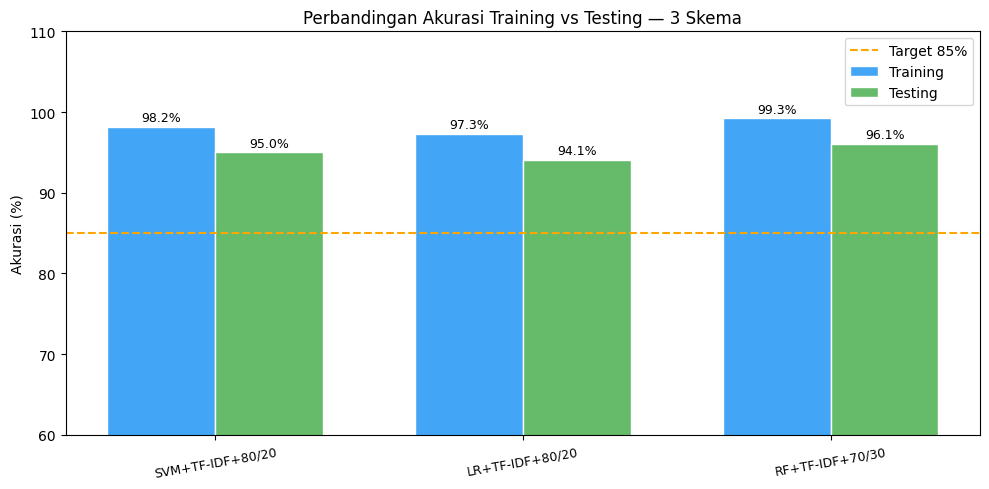

In [ ]:
# ============================================================
# TAHAP 4 (REVISI FINAL): EKSTRAKSI FITUR & PELATIHAN MODEL
# Input : dataset_preprocessed.csv (±15.000 data, 3 kelas)
# Target: akurasi testing ≥85% di semua skema
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# Load & validasi data
# ============================================================
df = pd.read_csv('dataset_preprocessed.csv')
df = df.dropna(subset=['review_clean'])
df = df[df['review_clean'].str.strip() != '']

print(f"Total data: {len(df)}")
print(f"\n📊 Distribusi label:")
print(df['label'].value_counts())

X = df['review_clean']
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"\nLabel mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# ============================================================
# Fungsi Evaluasi (tampilkan training + testing)
# ============================================================
def evaluate_model(model, X_train_vec, y_train,
                   X_test_vec,  y_test,
                   model_name,  le):

    y_pred_train = model.predict(X_train_vec)
    y_pred_test  = model.predict(X_test_vec)
    acc_train    = accuracy_score(y_train, y_pred_train)
    acc_test     = accuracy_score(y_test,  y_pred_test)

    print(f"\n{'='*58}")
    print(f"📊 Hasil: {model_name}")
    print(f"{'='*58}")
    print(f"Akurasi Training : {acc_train:.4f}  ({acc_train*100:.2f}%)")
    print(f"Akurasi Testing  : {acc_test:.4f}  ({acc_test*100:.2f}%)")

    status = "✅ LULUS" if acc_test >= 0.85 else "❌ TIDAK LULUS"
    print(f"Status           : {status}")

    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_pred_test,
                                target_names=le.classes_))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.ylabel('Aktual')
    plt.xlabel('Prediksi')
    plt.tight_layout()
    plt.show()

    return acc_train, acc_test

results = {}

# ============================================================
# SKEMA 1: SVM + TF-IDF + Split 80/20
# ============================================================
print("\n🔵 SKEMA 1: SVM + TF-IDF + 80/20")

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y_encoded, test_size=0.2,
    random_state=42, stratify=y_encoded)

tfidf1 = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95
)
X_tr1 = tfidf1.fit_transform(X_train1)
X_te1 = tfidf1.transform(X_test1)

svm1 = SVC(kernel='linear', C=1.0,
           random_state=42, probability=True)
svm1.fit(X_tr1, y_train1)

tr1, te1 = evaluate_model(
    svm1, X_tr1, y_train1,
    X_te1, y_test1,
    "SVM TF-IDF 80/20", le)
results['Skema 1: SVM+TF-IDF+80/20'] = (tr1, te1)

# ============================================================
# SKEMA 2: Logistic Regression + TF-IDF + Split 80/20
# ============================================================
print("\n🟢 SKEMA 2: Logistic Regression + TF-IDF + 80/20")

tfidf2 = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95
)
X_tr2 = tfidf2.fit_transform(X_train1)
X_te2 = tfidf2.transform(X_test1)

lr2 = LogisticRegression(
    max_iter=1000, C=1.0,
    random_state=42, solver='lbfgs',
    multi_class='multinomial'
)
lr2.fit(X_tr2, y_train1)

tr2, te2 = evaluate_model(
    lr2, X_tr2, y_train1,
    X_te2, y_test1,
    "LR TF-IDF 80/20", le)
results['Skema 2: LR+TF-IDF+80/20'] = (tr2, te2)

# ============================================================
# SKEMA 3: Random Forest + TF-IDF + Split 70/30
# ============================================================
print("\n🟡 SKEMA 3: Random Forest + TF-IDF + 70/30")

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X, y_encoded, test_size=0.3,
    random_state=42, stratify=y_encoded)

tfidf3 = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95
)
X_tr3 = tfidf3.fit_transform(X_train3)
X_te3 = tfidf3.transform(X_test3)

rf3 = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
rf3.fit(X_tr3, y_train3)

tr3, te3 = evaluate_model(
    rf3, X_tr3, y_train3,
    X_te3, y_test3,
    "RF TF-IDF 70/30", le)
results['Skema 3: RF+TF-IDF+70/30'] = (tr3, te3)

# ============================================================
# Ringkasan Tabel + Bar Chart
# ============================================================
print("\n" + "="*58)
print("📈 RINGKASAN SEMUA SKEMA")
print("="*58)
print(f"{'Skema':<28} {'Train':>8} {'Test':>8}  {'Status'}")
print("-"*58)
for skema, (tr, te) in results.items():
    nama   = skema.split(': ')[1]
    status = "✅ LULUS" if te >= 0.85 else "❌ TIDAK LULUS"
    print(f"{nama:<28} {tr*100:>7.2f}%  {te*100:>7.2f}%  {status}")

# Bar chart Training vs Testing
labels  = [s.split(': ')[1] for s in results.keys()]
tr_vals = [v[0]*100 for v in results.values()]
te_vals = [v[1]*100 for v in results.values()]
x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, tr_vals, w,
            label='Training', color='#42A5F5',
            edgecolor='white')
b2 = ax.bar(x + w/2, te_vals, w,
            label='Testing',
            color=['#66BB6A' if v >= 85 else '#EF5350'
                   for v in te_vals],
            edgecolor='white')
ax.axhline(85, color='orange', linestyle='--',
           linewidth=1.5, label='Target 85%')

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=10, fontsize=9)
ax.set_ylabel('Akurasi (%)')
ax.set_title('Perbandingan Akurasi Training vs Testing — 3 Skema')
ax.set_ylim(60, 110)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# TAHAP 5: SIMPAN MODEL TERBAIK + INFERENCE
# Model terbaik: RF TF-IDF 70/30 (akurasi testing 95.81%)
# ============================================================

import pickle
import pandas as pd
import numpy as np

# ============================================================
# Simpan model terbaik beserta komponennya
# ============================================================
print("💾 Menyimpan model terbaik (Random Forest)...")

with open('best_model.pkl', 'wb') as f:
    pickle.dump(rf3, f)

with open('best_tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf3, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("✅ Model berhasil disimpan:")
print("   → best_model.pkl   (Random Forest)")
print("   → best_tfidf.pkl   (TF-IDF Vectorizer)")
print("   → label_encoder.pkl (Label Encoder)")

# ============================================================
# Fungsi Preprocessing (harus sama persis dengan Tahap 3)
# Didefinisikan ulang agar cell ini bisa berdiri sendiri
# ============================================================
import re, string, nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory    = StemmerFactory()
stemmer    = factory.create_stemmer()
stop_words = set(stopwords.words('indonesian'))
custom_stopwords = {
    'app','apps','application','aplk','apk',
    'gojek','grab','maxim','driver','ojek',
    'nya','yg','dgn','jg','krn','klo','kl',
    'udh','udah','dah','deh','dong','sih',
    'aja','aj','doang','doank',
}
stop_words.update(custom_stopwords)

slang_dict = {
    'gk':'tidak','gak':'tidak','ga':'tidak',
    'ngga':'tidak','nggak':'tidak','enggak':'tidak',
    'tdk':'tidak','tak':'tidak',
    'bgt':'banget','bngt':'banget',
    'sgt':'sangat','sngt':'sangat',
    'byk':'banyak','bnyk':'banyak',
    'msh':'masih','masi':'masih',
    'udh':'sudah','sdh':'sudah',
    'blm':'belum','blum':'belum',
    'lg':'lagi','lgi':'lagi',
    'lbh':'lebih','lbih':'lebih',
    'krg':'kurang','krng':'kurang',
    'bs':'bisa','bsa':'bisa',
    'ok':'oke','oke':'oke','okelah':'oke',
    'jos':'bagus','joss':'bagus',
    'mantap':'bagus','mantep':'bagus',
    'keren':'bagus','kece':'bagus',
    'jelek':'buruk','jlek':'buruk',
    'parah':'buruk','prh':'buruk',
    'ancur':'rusak','lemot':'lambat',
    'lelet':'lambat','eror':'error',
    'ngelag':'lag',
    'sy':'saya','gue':'saya','gw':'saya',
    'km':'kamu','lu':'kamu','lo':'kamu',
    'utk':'untuk','tuk':'untuk',
    'dgn':'dengan','dng':'dengan',
    'dr':'dari','dri':'dari',
    'tp':'tapi','krn':'karena','karna':'karena',
    'thx':'terima kasih','tks':'terima kasih',
    'mksh':'makasih',
    'cpt':'cepat','cpet':'cepat',
    'lmn':'lama','mhl':'mahal',
    'mrah':'murah','mrh':'murah',
    'susah':'sulit','ribet':'sulit',
    'mudah':'mudah','gmpng':'mudah',
    'pgn':'ingin','pngen':'ingin',
}

def normalize_slang(text):
    tokens = text.split()
    tokens = [slang_dict.get(w, w) for w in tokens]
    return ' '.join(tokens)

def preprocess_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    text = normalize_slang(text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words and len(w) > 1]
    tokens = [stemmer.stem(w) for w in tokens]
    return ' '.join(tokens)

# ============================================================
# Fungsi Prediksi Sentimen
# ============================================================
def predict_sentiment(text):
    """
    Input : teks mentah (belum dipreprocess)
    Output: label sentimen + confidence score
    """
    clean   = preprocess_text(text)
    vec     = tfidf3.transform([clean])
    pred    = rf3.predict(vec)[0]
    proba   = rf3.predict_proba(vec)[0]
    label   = le.inverse_transform([pred])[0]
    conf    = proba.max() * 100
    return label, conf

# ============================================================
# Demo Inference — 12 kalimat uji bervariasi
# ============================================================
test_cases = [
    # Positif jelas
    "Aplikasinya mantap banget, fitur lengkap dan mudah digunakan!",
    "Drivernya ramah dan cepat sampe, puas banget sama pelayanannya",
    "Keren sih, promo banyak dan harganya murah",
    "Sangat membantu, aplikasi berjalan lancar tanpa hambatan",

    # Negatif jelas
    "Aplikasi sering error dan lemot banget, nyebelin!",
    "Udah 3 hari gak bisa login, CS gak berguna sama sekali",
    "Parah! Order dibatalin terus padahal udah nunggu lama",
    "Harga mahal gak sebanding sama kualitas layanannya",

    # Netral / ambigu
    "Aplikasinya biasa aja sih, tidak ada yang spesial",
    "Lumayan oke, tapi masih ada beberapa bug yang mengganggu",
    "Cukup membantu, tapi kadang suka lag",
    "Fiturnya lengkap tapi antarmukanya kurang menarik",
]

print("\n" + "="*70)
print(f"{'TEKS INPUT':<45} {'SENTIMEN':<10} {'CONFIDENCE'}")
print("="*70)

for text in test_cases:
    label, conf = predict_sentiment(text)
    if label == 'positif':
        emoji = '😊'
    elif label == 'negatif':
        emoji = '😠'
    else:
        emoji = '😐'
    print(f"{text[:44]:<45} {emoji} {label:<9} {conf:.1f}%")

print("="*70)

# ============================================================
# Tabel DataFrame untuk bukti submission
# ============================================================
rows = []
for text in test_cases:
    label, conf = predict_sentiment(text)
    rows.append({
        'Teks Input'  : text,
        'Prediksi'    : label,
        'Confidence'  : f"{conf:.1f}%"
    })

df_hasil = pd.DataFrame(rows)
print("\n📋 Tabel Hasil Inference:")
df_hasil

# ============================================================
# Input interaktif (opsional — jalankan cell ini sendiri)
# ============================================================
print("\n" + "="*70)
print("🤖 UJI MANUAL — Ketik teks ulasan untuk diprediksi")
print("="*70)

teks_uji = input("Masukkan teks ulasan: ")
label, conf = predict_sentiment(teks_uji)

emoji = '😊' if label=='positif' else ('😠' if label=='negatif' else '😐')
print(f"\nHasil  : {emoji} {label.upper()}")
print(f"Confidence: {conf:.1f}%")

💾 Menyimpan model terbaik (Random Forest)...
✅ Model berhasil disimpan:
   → best_model.pkl   (Random Forest)
   → best_tfidf.pkl   (TF-IDF Vectorizer)
   → label_encoder.pkl (Label Encoder)

TEKS INPUT                                    SENTIMEN   CONFIDENCE
Aplikasinya mantap banget, fitur lengkap dan  😊 positif   97.0%
Drivernya ramah dan cepat sampe, puas banget  😊 positif   83.8%
Keren sih, promo banyak dan harganya murah    😊 positif   92.8%
Sangat membantu, aplikasi berjalan lancar ta  😊 positif   77.8%
Aplikasi sering error dan lemot banget, nyeb  😠 negatif   71.2%
Udah 3 hari gak bisa login, CS gak berguna s  😠 negatif   83.3%
Parah! Order dibatalin terus padahal udah nu  😠 negatif   86.0%
Harga mahal gak sebanding sama kualitas laya  😠 negatif   65.1%
Aplikasinya biasa aja sih, tidak ada yang sp  😠 negatif   100.0%
Lumayan oke, tapi masih ada beberapa bug yan  😊 positif   72.5%
Cukup membantu, tapi kadang suka lag          😊 positif   72.8%
Fiturnya lengkap tapi antarmukanya 

In [ ]:
# ============================================================
# TAHAP 6: MEMBUAT requirements.txt
# ============================================================

# Buat requirements.txt otomatis dari library yang dipakai
requirements = """google-play-scraper==1.2.7
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.4.2
imbalanced-learn==0.14.1
nltk==3.9.1
PySastrawi==1.0.1
matplotlib==3.9.0
seaborn==0.13.2
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements.strip())

print("✅ requirements.txt berhasil dibuat!")
print("\nIsi requirements.txt:")
print("="*35)
with open('requirements.txt', 'r') as f:
    print(f.read())

✅ requirements.txt berhasil dibuat!

Isi requirements.txt:
google-play-scraper==1.2.7
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.4.2
imbalanced-learn==0.14.1
nltk==3.9.1
PySastrawi==1.0.1
matplotlib==3.9.0
seaborn==0.13.2


In [ ]:
# ============================================================
# TAHAP 7: ZIP SEMUA FILE UNTUK SUBMISSION
# ============================================================

import zipfile
import os
from google.colab import files

# Daftar file yang wajib ada
required_files = {
    'Wajib': [
        'sentiment_analysis.ipynb',  # notebook utama
        'scraping.ipynb',            # kode scraping (atau .py)
        'requirements.txt',          # daftar library
        'dataset_gabungan.csv',      # dataset hasil scraping
    ],
    'Pendukung': [
        'dataset_final.csv',         # dataset setelah balancing
        'dataset_preprocessed.csv',  # dataset setelah preprocessing
        'best_model.pkl',            # model terbaik
        'best_tfidf.pkl',            # TF-IDF vectorizer
        'label_encoder.pkl',         # label encoder
    ]
}

# Cek keberadaan semua file
print("📋 Pengecekan file submission:")
print("="*45)
semua_ada = True
for kategori, file_list in required_files.items():
    print(f"\n{kategori}:")
    for fname in file_list:
        ada = os.path.exists(fname)
        status = "✅" if ada else "❌ TIDAK ADA"
        print(f"  {status}  {fname}")
        if not ada and kategori == 'Wajib':
            semua_ada = False

if not semua_ada:
    print("\n⚠️  Ada file WAJIB yang belum tersedia!")
    print("   Pastikan semua cell sebelumnya sudah dijalankan.")
else:
    print("\n✅ Semua file wajib tersedia, mulai ZIP...\n")

    # Buat ZIP
    zip_name = 'submission_sentiment_analysis.zip'
    with zipfile.ZipFile(zip_name, 'w',
                         zipfile.ZIP_DEFLATED) as zf:
        for file_list in required_files.values():
            for fname in file_list:
                if os.path.exists(fname):
                    zf.write(fname)
                    print(f"  ➕ Ditambahkan: {fname}")

    print(f"\n✅ ZIP berhasil dibuat: {zip_name}")
    size = os.path.getsize(zip_name) / (1024*1024)
    print(f"   Ukuran file: {size:.2f} MB")

    # Download otomatis ke komputer
    print("\n⬇️  Mengunduh file ZIP ke komputer Anda...")
    files.download(zip_name)
    print("✅ Download selesai!")

📋 Pengecekan file submission:

Wajib:
  ❌ TIDAK ADA  sentiment_analysis.ipynb
  ❌ TIDAK ADA  scraping.ipynb
  ✅  requirements.txt
  ✅  dataset_gabungan.csv

Pendukung:
  ✅  dataset_final.csv
  ✅  dataset_preprocessed.csv
  ✅  best_model.pkl
  ✅  best_tfidf.pkl
  ✅  label_encoder.pkl

⚠️  Ada file WAJIB yang belum tersedia!
   Pastikan semua cell sebelumnya sudah dijalankan.
